# Machine Learning 1 - Übung: Adipositas Prediction



**🏥 Die spannende Frage:** Kann ein Computer Adipositas ohne Angaben zu Größe und Gewicht erkennen?

## Dataset: NHANES 08/2021 - 08/2023

**1653 Probanden**

**Ziel:** Vorhersage ob Adipositas vorliegt (BMI_cat: 0 = normal (BMI <25kg/m2, Untergewichtige wurden rausgefiltert), 1 = übergewichtig (BMI <30kg/m2), 2 = adipös (BMI >= 30kg/m2))

**Quelle:** https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2021-2023

## Teil 1: Setup

In [1]:
# Bibliotheken
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Visualisierung
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(" Setup komplett")

 Setup komplett


In [2]:
# Daten laden (bereinigte Version aus Woche 7)
df = pd.read_csv('obesity_cleaned.csv')

print(f" Datensatz: {df.shape[0]} Patienten, {df.shape[1]} Features")
print(f"\n Erste 5 Zeilen:")
display(df.head())

 Datensatz: 1653 Patienten, 17 Features

 Erste 5 Zeilen:


,id,gender,age,education_lvl,income,kcal,protein,carbs,sugar,fiber,fat,alcohol,sedentary_act_min,smoke_status,activity_level,sleep_avg,bmi_cat
0,130379,1.0,66,5.0,5.00,2741.0,86.45,314.86,113.58,29.6,67.18,4,480.0,1.0,1,9.0,2
1,130386,1.0,34,4.0,1.33,2422.0,132.41,207.53,37.89,25.1,116.54,3,180.0,1.0,0,7.6,2
2,130389,1.0,59,5.0,5.00,1991.0,89.50,118.64,52.67,6.7,98.03,4,720.0,1.0,1,8.0,1
3,130394,1.0,51,5.0,5.00,1613.0,75.06,207.20,64.46,19.7,55.44,2,420.0,0.0,1,8.0,0
4,130398,1.0,47,3.0,1.67,1109.0,32.42,195.50,82.65,24.7,12.95,3,60.0,0.0,2,5.1,1


### Legende:
- gender: 1 = Mann, 2 = Frau (divers wurde nicht abgefragt)
- age: gecappt bei 20 (jüngere Probanden wurden rausgefiltert) und 80 (80 steht für 80 Jahre und älter)
- education_lvl:
  - 1 = unter 9. Klasse
  - 2 = 9.-11. Klasse (einschließlich 12. Klasse ohne Abschluss)
  - 3 = High school Absolvent oder gleichwertig
  - 4 = irgendein College oder AA Abschluss
  - 5 =	College Absolvent oder höher
- income: Einkommens-Armuts-Verhältnis zwischen 0.0 bis 5 (gecappt bei 5, 5 steht für >=5)
  - < 1.0: Das Haushaltseinkommen liegt unter der offiziellen Armutsgrenze.
  - = 1.0: Das Haushaltseinkommen entspricht der offiziellen Armutsgrenze.
  - \> 1.0: Das Haushaltseinkommen liegt über der offiziellen Armutsgrenze.
- kcal: Angabe pro Tag
- protein, carbs, sugar, fiber, fat: Angabe in Gramm/Tag
- alcohol:
  -  0 = nie
  -  1 = selten (1-2x bis 7-11x pro Jahr)
  -  2 = moderat (einmal pro Monat bis einmal pro Woche)
  -  3 = häufig (2x/Woche bis fast täglich)
  -  4 = fast täglich bis täglich
- sedentary_act_min: Minuten, die täglich sitzend verbracht werden (Schlaf ausgenommen)
- smoke_status:
  - 0 = nie
  - 1 = Ex-Raucher
  - 2 = aktiver Raucher
- activity_level:
  - 0 = inaktiv
  - 1 = moderat aktiv
  - 2 = sehr aktiv
- sleep_avg: durschnittliger täglicher Schlaf in Stunden
- BMI:
  - 0 = normal (BMI <25kg/m2, Untergewichtige wurden rausgefiltert)
  - 1 = übergewichtig (BMI <30kg/m2)
  - 2 = adipös (BMI >= 30kg/m2)

## Teil 2: Explorative Analyse - Wie viele sind adipös?

**Wichtig für ML:** Ist das Dataset balanciert?

Verteilung normalgewichtig (0) / übergewichtig (1) / adipös (2):
bmi_cat
0    502
1    594
2    557
Name: count, dtype: int64

Anteile in %:
bmi_cat
0    30.4%
1    35.9%
2    33.7%
Name: proportion, dtype: str


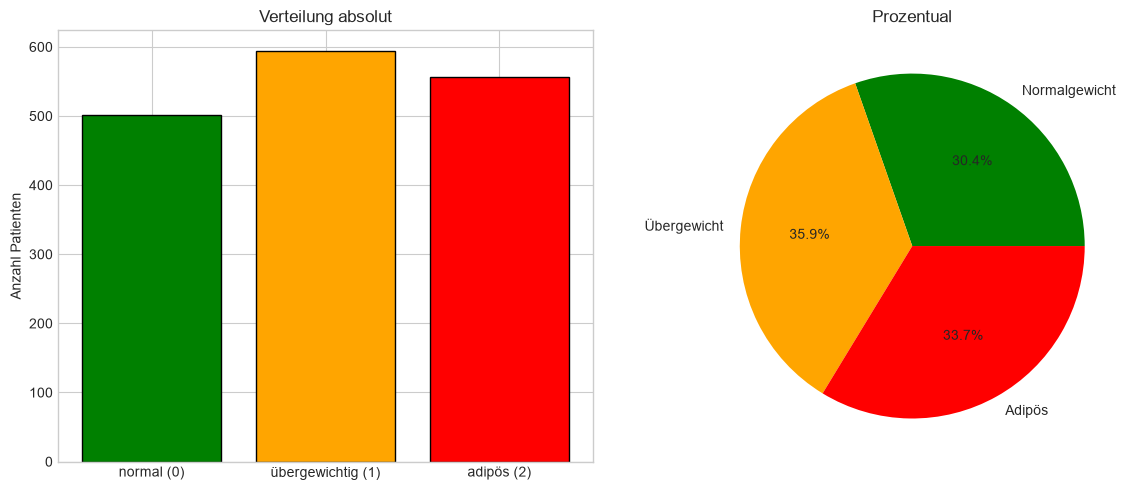


 Dataset ist balanciert (~30,4% normalgewichtig, ~35,9% übergewichtig, ~33,7% adipös) --> Gut für ML!


In [3]:
# Target-Verteilung
print("Verteilung normalgewichtig (0) / übergewichtig (1) / adipös (2):")
print(df['bmi_cat'].value_counts().sort_index())
print("\nAnteile in %:")
print(df['bmi_cat'].value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')

# Visualisierung
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

bmi_counts = df['bmi_cat'].value_counts().sort_index()
ax[0].bar(['normal (0)', 'übergewichtig (1)', 'adipös (2)'], bmi_counts.values, 
          color=['green', 'orange', 'red'], edgecolor='black')
ax[0].set_ylabel('Anzahl Patienten')
ax[0].set_title('Verteilung absolut')

ax[1].pie(bmi_counts.values, labels=['Normalgewicht', 'Übergewicht', 'Adipös'], 
          autopct='%1.1f%%', colors=['green', 'orange', 'red'])
ax[1].set_title('Prozentual')

plt.tight_layout()
plt.show()

print("\n Dataset ist balanciert (~30,4% normalgewichtig, ~35,9% übergewichtig, ~33,7% adipös) --> Gut für ML!")

## Teil 3: Feature Selection - Welche Risikofaktoren sind wichtig?

**Die spannende Frage:** Was erhöht das Risiko für Adipositas?

Achtung: Hier handelt es sich anders als im Heart Disease Beispiel um drei Kategorien.

Korrelation mit Adipositas:
sedentary_act_min    0.038193
smoke_status         0.037331
age                  0.002316
protein             -0.007038
fat                 -0.011160
sugar               -0.012765
kcal                -0.028891
carbs               -0.046374
gender              -0.063287
income              -0.070107
sleep_avg           -0.097777
alcohol             -0.098993
activity_level      -0.118189
fiber               -0.123274
education_lvl       -0.132396
Name: bmi_cat, dtype: float64


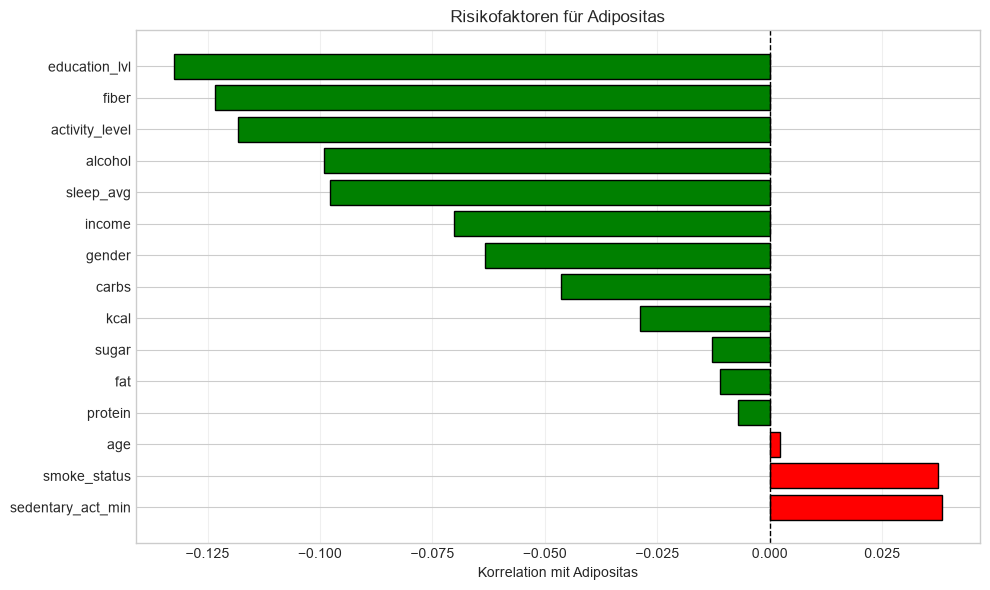


Größtes Risiko (positiv): sedentary_act_min (0.04)
   --> Höhere Werte = höheres Adipositasrisiko

 Größter Schutz (negativ): education_lvl (-0.13)
   --> Höhere Werte = niedrigeres Risiko

 Merke: Korrelation zeigt statistische Zusammenhänge, nicht Ursache!



In [4]:
# Nur numerische Spalten für Korrelation
target_corr = df.corr(numeric_only=True)['bmi_cat'].sort_values(ascending=False)
target_corr = target_corr.drop('id') # ohne id

print("Korrelation mit Adipositas:")
print(target_corr[1:])  # Ohne condition selbst

# Visualisierung
plt.figure(figsize=(10, 6))
corr_plot = target_corr[1:]  # Ohne condition
colors = ['red' if x > 0 else 'green' for x in corr_plot.values]
plt.barh(range(len(corr_plot)), corr_plot.values, color=colors, edgecolor='black')
plt.yticks(range(len(corr_plot)), corr_plot.index)
plt.xlabel('Korrelation mit Adipositas')
plt.title('Risikofaktoren für Adipositas')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGrößtes Risiko (positiv): {target_corr.index[1]} ({target_corr.values[1]:.2f})")
print(f"   --> Höhere Werte = höheres Adipositasrisiko")

print(f"\n Größter Schutz (negativ): {target_corr.index[-1]} ({target_corr.values[-1]:.2f})")  
print(f"   --> Höhere Werte = niedrigeres Risiko")

print("\n Merke: Korrelation zeigt statistische Zusammenhänge, nicht Ursache!")
print()

### Vergleich Korrelation mit Spearman, da bmi_cat ordinal ist 0 < 1 < 2

Spearman-Korrelation mit Adipositas:
smoke_status         0.044574
sedentary_act_min    0.035501
age                  0.001273
fat                 -0.017272
protein             -0.026283
kcal                -0.029894
sugar               -0.032699
carbs               -0.053280
gender              -0.061451
income              -0.082614
alcohol             -0.102070
sleep_avg           -0.111333
activity_level      -0.117977
fiber               -0.126655
education_lvl       -0.155620
Name: bmi_cat, dtype: float64


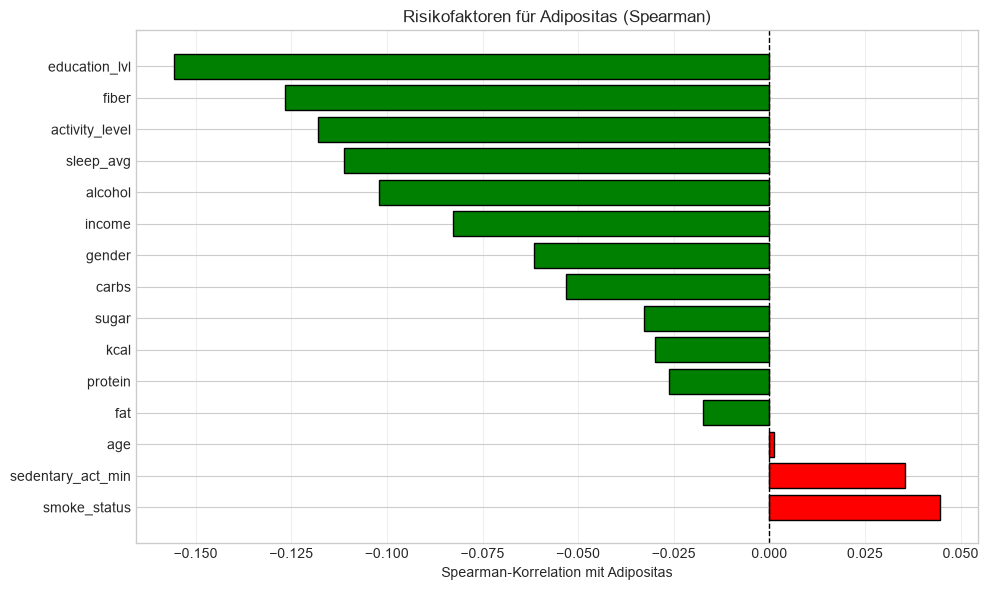


Größtes Risiko (positiv): smoke_status (0.04)
   → Höhere Werte = höheres Adipositasrisiko

 Größter Schutz (negativ): education_lvl (-0.16)
   → Höhere Werte = niedrigeres Risiko

 Merke: Spearman misst monotone Zusammenhänge (Rangfolge), nicht nur lineare wie Pearson!


In [5]:
target_corr_spearman = df.corr(method='spearman', numeric_only=True)['bmi_cat'].sort_values(ascending=False)
target_corr_spearman = target_corr_spearman.drop('id')
print("Spearman-Korrelation mit Adipositas:")
print(target_corr_spearman[1:])  # Ohne bmi_cat selbst

# Visualisierung
plt.figure(figsize=(10, 6))
corr_plot_sp = target_corr_spearman[1:]  # Ohne bmi_cat
colors_sp = ['red' if x > 0 else 'green' for x in corr_plot_sp.values]
plt.barh(range(len(corr_plot_sp)), corr_plot_sp.values, color=colors_sp, edgecolor='black')
plt.yticks(range(len(corr_plot_sp)), corr_plot_sp.index)
plt.xlabel('Spearman-Korrelation mit Adipositas')
plt.title('Risikofaktoren für Adipositas (Spearman)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nGrößtes Risiko (positiv): {target_corr_spearman.index[1]} ({target_corr_spearman.values[1]:.2f})")
print(f"   → Höhere Werte = höheres Adipositasrisiko")
print(f"\n Größter Schutz (negativ): {target_corr_spearman.index[-1]} ({target_corr_spearman.values[-1]:.2f})")
print(f"   → Höhere Werte = niedrigeres Risiko")
print("\n Merke: Spearman misst monotone Zusammenhänge (Rangfolge), nicht nur lineare wie Pearson!")

Die Rangfolge der Korrelation ist weitestgehend gleich geblieben. Insgesamt fällt auf, dass nur schwache Korrelationen vorhanden sind. Der Betrag der stärksten Korrelation ist nur ~0,16. Für ML müssen also wahrscheinlich mehrere Variablen einbezogen werden. <br> <br>
Wichtig zu beachten ist bei der Interpretation außerdem, dass viele der Kategorien nicht wirklich numerisch sind, sondern eigentlich kategorial, aber durch Zahlen codiert. Bei vielen ergibt die Korrelationsanalyse trotzdem Sinn, da sie ordinal sind. Die Kategorien, bei denen das nicht so ist, sind gender und smoke_status. Da gender binär ist, kann man die Korrelationsanalyse trotzdem sinnvoll interpretieren: höhere Werte (also Frauen), gehen mit einem geringeren Adipositas-Risiko einher. <br>
Smoke_status ist aber nicht ordinal (siehe Legende), hier ist eine genauere Einzel-Betrachtung sinnvoll.

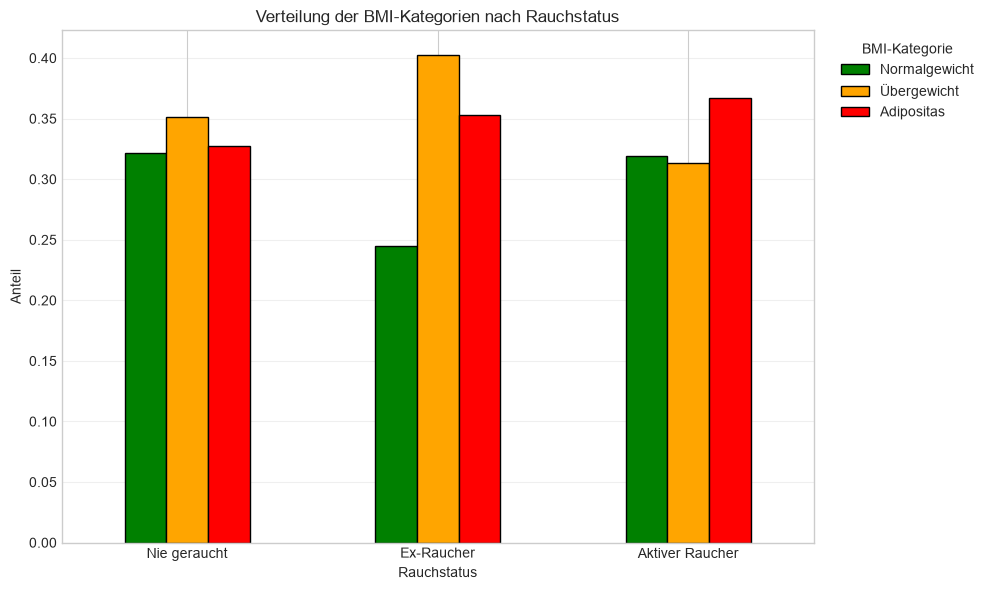

bmi_cat          Normalgewicht  Übergewicht  Adipositas
smoke_status                                           
Nie geraucht             0.322        0.351       0.327
Ex-Raucher               0.245        0.403       0.353
Aktiver Raucher          0.320        0.314       0.367


In [6]:
# Visualisierung: Verteilung der BMI-Kategorien nach Rauchstatus
smoke_bmi = df.groupby('smoke_status')['bmi_cat'].value_counts(normalize=True).unstack()

# Beschriftungen für bessere Lesbarkeit
smoke_labels = {0: 'Nie geraucht', 1: 'Ex-Raucher', 2: 'Aktiver Raucher'}
bmi_labels = {0: 'Normalgewicht', 1: 'Übergewicht', 2: 'Adipositas'}

smoke_bmi.index = smoke_bmi.index.map(smoke_labels)
smoke_bmi.columns = smoke_bmi.columns.map(bmi_labels)

# Plot
smoke_bmi.plot(kind='bar', stacked=False, figsize=(10, 6),
               color=['green', 'orange', 'red'], edgecolor='black')

plt.title('Verteilung der BMI-Kategorien nach Rauchstatus')
plt.xlabel('Rauchstatus')
plt.ylabel('Anteil')
plt.xticks(rotation=0)
plt.legend(title='BMI-Kategorie', loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(smoke_bmi.round(3))

Es fällt vor allem auf, dass Ex-Raucher den geringsten Anteil an Normalgewichtigen und gleichzeitig den höchsten Anteil an Übergewichtigen haben.

Ich habe mich schließlich dazu entschieden für smoke_status one hot encoding anzuwenden.

## Teil 4: Daten für ML vorbereiten

In [7]:
# One-Hot-Encoding für smoke_status
smoke_labels = {0: 'nie', 1: 'ex', 2: 'aktiv'}
df_encoded = pd.get_dummies(df.assign(smoke_status=df['smoke_status'].map(smoke_labels)),
                             columns=['smoke_status'], prefix='smoke')
# Kontrolle: neue Spalten anzeigen
print(df_encoded.filter(like='smoke').head())

   smoke_aktiv  smoke_ex  smoke_nie
0        False      True      False
1        False      True      False
2        False      True      False
3        False     False       True
4        False     False       True


In [8]:
# Features (X) und Target (Y)
Y = df_encoded['bmi_cat']
X = df_encoded.drop('bmi_cat', axis=1).select_dtypes(include=['int64', 'float64', 'bool'])
X = X.drop('id', axis=1)

print(f"Features (X): {X.shape}")
print(f"Target (Y): {Y.shape}")
print(f"\nVerwendete Features: {X.columns.tolist()}")

Features (X): (1653, 17)
Target (Y): (1653,)

Verwendete Features: ['gender', 'age', 'education_lvl', 'income', 'kcal', 'protein', 'carbs', 'sugar', 'fiber', 'fat', 'alcohol', 'sedentary_act_min', 'activity_level', 'sleep_avg', 'smoke_aktiv', 'smoke_ex', 'smoke_nie']


In [9]:
# Train/Test Split (80/20, stratified)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y  # Erhält Verteilung
)

print(f"Training Set: {len(X_train)} Patienten ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test Set: {len(X_test)} Patienten ({len(X_test)/len(X)*100:.0f}%)")

print("\nTarget-Verteilung im Trainingsset:")
print(Y_train.value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')

print("\nTarget-Verteilung im Testset:")
print(Y_test.value_counts(normalize=True).sort_index().mul(100).round(1).astype(str) + '%')

Training Set: 1322 Patienten (80%)
Test Set: 331 Patienten (20%)

Target-Verteilung im Trainingsset:
bmi_cat
0    30.4%
1    35.9%
2    33.7%
Name: proportion, dtype: str

Target-Verteilung im Testset:
bmi_cat
0    30.2%
1    36.0%
2    33.8%
Name: proportion, dtype: str


## Teil 5: Modellvergleich - Welcher Algorithmus ist am besten?

Ich musste hier die maximalen Iterationen für die logistische Regression erhöhen, da mehr Iterationen erforderlich waren. Selbst 10000 Iterationen reichten noch nicht aus. Deshalb habe ich den solver auf "saga" gewechselt, was für Multi-Class-Probleme robuster sein kann. Daraufhin konvergierte das Modell mit 5000 Iterationen vollständig.

In [10]:
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Definiere Modelle

models = {
    'Nearest Centroid': NearestCentroid(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=5000, solver='saga', random_state=42),
    'Naive Bayes': GaussianNB()
}

print(f"✓ {len(models)} Modelle definiert")

✓ 6 Modelle definiert


In [11]:
# Trainieren und Evaluieren
results = []

for name, model in models.items():
    model.fit(X_train, Y_train)
    
    train_acc = model.score(X_train, Y_train)
    test_acc = model.score(X_test, Y_test)
    
    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Overfitting Gap': train_acc - test_acc
    })
    
    print(f"✓ {name:25s} - Train: {train_acc:.2%} | Test: {test_acc:.2%}")

# DataFrame
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print(" ERGEBNISSE (sortiert nach Test Accuracy):")
print("="*70)
display(results_df.style.format({
    'Train Accuracy': '{:.2%}',
    'Test Accuracy': '{:.2%}',
    'Overfitting Gap': '{:.2%}'
}))

✓ Nearest Centroid          - Train: 35.93% | Test: 33.53%
✓ K-Nearest Neighbors       - Train: 54.69% | Test: 35.35%
✓ Decision Tree             - Train: 53.33% | Test: 35.35%
✓ Random Forest             - Train: 66.11% | Test: 41.69%
✓ Logistic Regression       - Train: 40.17% | Test: 40.48%
✓ Naive Bayes               - Train: 44.40% | Test: 38.67%

 ERGEBNISSE (sortiert nach Test Accuracy):


,Model,Train Accuracy,Test Accuracy,Overfitting Gap
0,Random Forest,66.11%,41.69%,24.42%
1,Logistic Regression,40.17%,40.48%,-0.32%
2,Naive Bayes,44.40%,38.67%,5.73%
3,K-Nearest Neighbors,54.69%,35.35%,19.34%
4,Decision Tree,53.33%,35.35%,17.98%
5,Nearest Centroid,35.93%,33.53%,2.40%


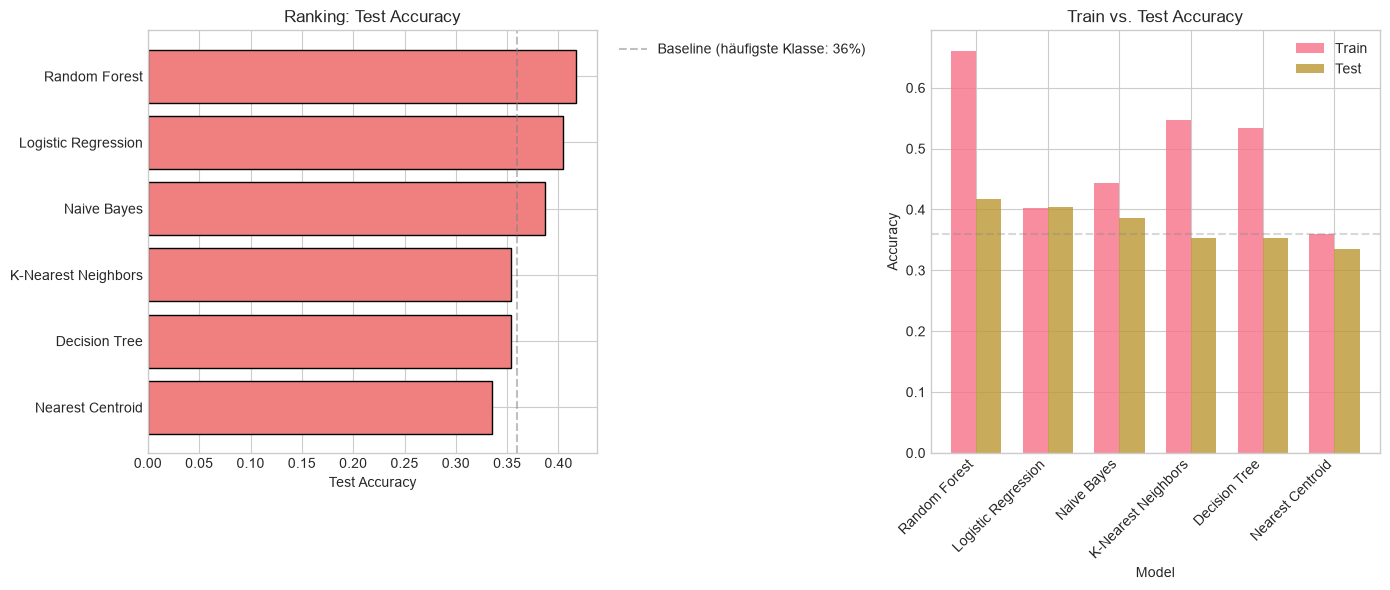


 Bestes Modell: Random Forest (41.69%)


In [12]:
# Visualisierung: Train vs Test
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Test Accuracy Ranking
colors = ['lightcoral' if x < 0.45 else 'lightgreen' for x in results_df['Test Accuracy']]
ax[0].barh(range(len(results_df)), results_df['Test Accuracy'], color=colors, edgecolor='black')
ax[0].set_yticks(range(len(results_df)))
ax[0].set_yticklabels(results_df['Model'])
ax[0].set_xlabel('Test Accuracy')
ax[0].set_title('Ranking: Test Accuracy')
ax[0].axvline(x=0.36, color='gray', linestyle='--', alpha=0.5, label='Baseline (häufigste Klasse: 36%)')
ax[0].legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax[0].invert_yaxis()

# Plot 2: Train vs Test
x_pos = np.arange(len(results_df))
width = 0.35
ax[1].bar(x_pos - width/2, results_df['Train Accuracy'], width, label='Train', alpha=0.8)
ax[1].bar(x_pos + width/2, results_df['Test Accuracy'], width, label='Test', alpha=0.8)
ax[1].set_xlabel('Model')
ax[1].set_ylabel('Accuracy')
ax[1].set_title('Train vs. Test Accuracy')
ax[1].set_xticks(x_pos)
ax[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax[1].legend()
ax[1].axhline(y=0.36, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n Bestes Modell: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Test Accuracy']:.2%})")

## Teil 6: Visualisierung - Bestes vs. Schlechtestes Modell

**Confusion Matrix:** Wo machen die Modelle Fehler?

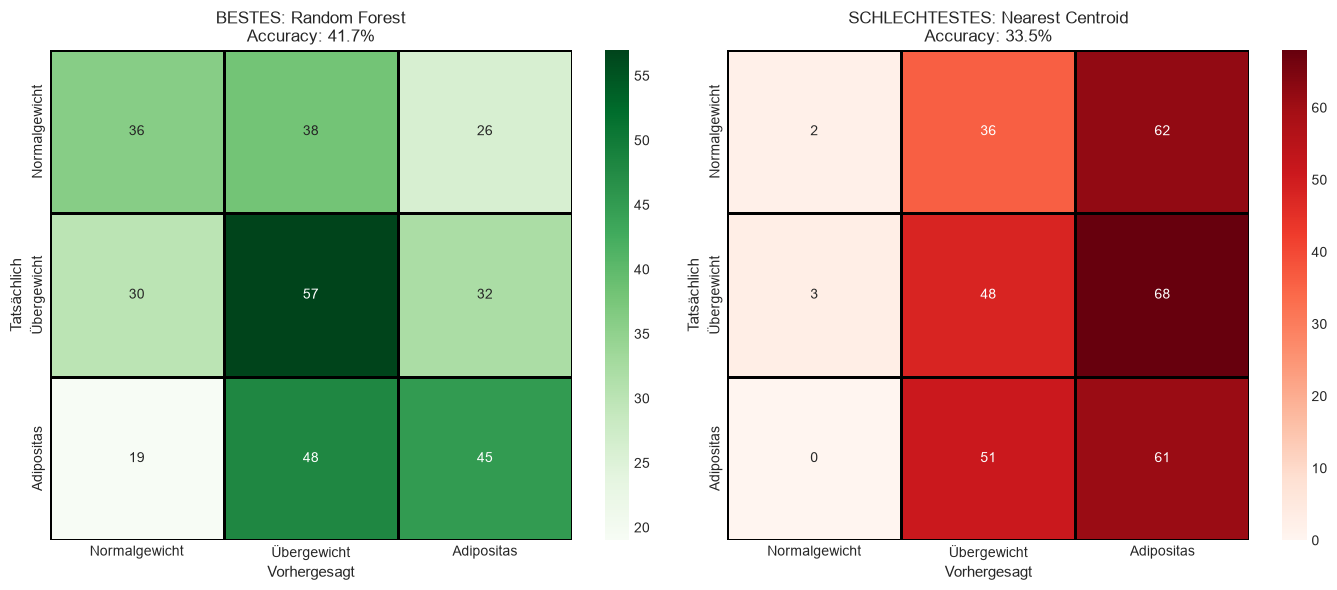


 Confusion Matrix lesen:
   - Diagonale: Richtige Vorhersagen ✓
   - Alle Felder außerhalb der Diagonale: Fehlklassifikationen zwischen den drei Kategorien
   - Besonders relevant: Wird Adipositas als Normalgewicht eingestuft (unten links)?

 Im gesundheitlichen Kontext:
   Adipositas als Normalgewicht verkannt → Risiko wird unterschätzt, kritisch!
   Normalgewicht als Adipositas eingestuft → Unnötige Sorge, weniger kritisch


In [13]:
# Bestes und Schlechtestes Modell
best_name = results_df.iloc[0]['Model']
worst_name = results_df.iloc[-1]['Model']

best_model = models[best_name]
worst_model = models[worst_name]

# Vorhersagen - Modelle sind bereits trainiert
y_pred_best = best_model.predict(X_test)
y_pred_worst = worst_model.predict(X_test)

# Confusion Matrices
cm_best = confusion_matrix(Y_test, y_pred_best)
cm_worst = confusion_matrix(Y_test, y_pred_worst)

# Beschriftung für die drei BMI-Kategorien
bmi_labels = ['Normalgewicht', 'Übergewicht', 'Adipositas']

# Visualisierung
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# BESTES Modell
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=bmi_labels, yticklabels=bmi_labels,
            ax=ax[0], cbar=True, linewidths=1, linecolor='black')
ax[0].set_xlabel('Vorhergesagt', fontsize=11)
ax[0].set_ylabel('Tatsächlich', fontsize=11)
ax[0].set_title(f'BESTES: {best_name}\nAccuracy: {results_df.iloc[0]["Test Accuracy"]:.1%}',
                fontsize=12)

# SCHLECHTESTES Modell
sns.heatmap(cm_worst, annot=True, fmt='d', cmap='Reds',
            xticklabels=bmi_labels, yticklabels=bmi_labels,
            ax=ax[1], cbar=True, linewidths=1, linecolor='black')
ax[1].set_xlabel('Vorhergesagt', fontsize=11)
ax[1].set_ylabel('Tatsächlich', fontsize=11)
ax[1].set_title(f'SCHLECHTESTES: {worst_name}\nAccuracy: {results_df.iloc[-1]["Test Accuracy"]:.1%}',
                fontsize=12)

plt.tight_layout()
plt.show()

print("\n Confusion Matrix lesen:")
print("   - Diagonale: Richtige Vorhersagen ✓")
print("   - Alle Felder außerhalb der Diagonale: Fehlklassifikationen zwischen den drei Kategorien")
print("   - Besonders relevant: Wird Adipositas als Normalgewicht eingestuft (unten links)?")
print("\n Im gesundheitlichen Kontext:")
print("   Adipositas als Normalgewicht verkannt → Risiko wird unterschätzt, kritisch!")
print("   Normalgewicht als Adipositas eingestuft → Unnötige Sorge, weniger kritisch")

In [14]:
# Detailanalyse: Wie gut wird Adipositas erkannt?

bmi_labels_short = ['Normalgewicht', 'Übergewicht', 'Adipositas']

def adipositas_analyse(cm, name):
    # Adipositas = Klasse 2 (letzte Zeile/Spalte in der Matrix)
    tatsaechlich_adipoes = cm[2, :].sum()
    korrekt_erkannt = cm[2, 2]
    als_normal_verkannt = cm[2, 0]
    als_uebergewicht_verkannt = cm[2, 1]
    
    print(f"\n{name}:")
    print(f"   + Adipositas richtig erkannt: {korrekt_erkannt} von {tatsaechlich_adipoes} ({korrekt_erkannt/tatsaechlich_adipoes*100:.1f}%)")
    print(f"   - Als Normalgewicht verkannt: {als_normal_verkannt} (kritisch - Risiko wird komplett übersehen!)")
    print(f"   - Als Übergewicht verkannt: {als_uebergewicht_verkannt} (auch kritisch - Risiko wird unterschätzt!)")

print("\n GESUNDHEITLICHE BEWERTUNG:")
print("="*70)
adipositas_analyse(cm_best, best_name)
adipositas_analyse(cm_worst, worst_name)

print("\nFazit: Das schlechtere Modell stuft zwar mehr Adipöse richtig ein und verkennt keine Adipösen als "
"normalgewichtig, verkennt aber mehr Adipöse als übergewichtig und stuft insgesamt kaum Patienten als "
"normalgewichtig, mehr als übergewichtig und noch mehr als adipös ein.")

# Ergänzend: vollständiger Classification Report mit Precision/Recall/F1 pro Klasse
print("\n" + "="*70)
print(f" Detaillierter Report – {best_name}:")
print("="*70)
print(classification_report(Y_test, y_pred_best, target_names=bmi_labels_short))


 GESUNDHEITLICHE BEWERTUNG:

Random Forest:
   + Adipositas richtig erkannt: 45 von 112 (40.2%)
   - Als Normalgewicht verkannt: 19 (kritisch - Risiko wird komplett übersehen!)
   - Als Übergewicht verkannt: 48 (auch kritisch - Risiko wird unterschätzt!)

Nearest Centroid:
   + Adipositas richtig erkannt: 61 von 112 (54.5%)
   - Als Normalgewicht verkannt: 0 (kritisch - Risiko wird komplett übersehen!)
   - Als Übergewicht verkannt: 51 (auch kritisch - Risiko wird unterschätzt!)

Fazit: Das schlechtere Modell stuft zwar mehr Adipöse richtig ein und verkennt keine Adipösen als normalgewichtig, verkennt aber mehr Adipöse als übergewichtig und stuft insgesamt kaum Patienten als normalgewichtig, mehr als übergewichtig und noch mehr als adipös ein.

 Detaillierter Report – Random Forest:
               precision    recall  f1-score   support

Normalgewicht       0.42      0.36      0.39       100
  Übergewicht       0.40      0.48      0.44       119
   Adipositas       0.44      0.40     

Selbst das beste Modell erkennt nur 40,2% der Adipösen und verkennt somit knapp 60%. Es ist mit einer Accuracy von 41,69% nur ca. 5,7 pp besser als einfach jedes Mal die häufigste Kategorie zu raten.